In [22]:
from pathlib import Path
import selfmadefunctions
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

Selfmadefuntions imported/reloaded


<module 'selfmadefunctions' from 'c:\\Users\\DTA180363\\Documents\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

This notebook is used to process the experiments I'm doing during my thesis. 

The cell below is used to read and track the videos, and save the y-coordinates into a CSV file (the y coordinates are already normalized). 

Having problems? Look at the outputfolder to see what part of tracking went wrong. Tweak the function accordingly 

(within selfmadefunctions.py there is a variabele named "treshold_value", that's probably the one to tweak. It might be worth it to make treshold_value one of the input parameters instead of a set value within the function).

In [23]:
importlib.reload(selfmadefunctions)

inputfolder = Path(rf"Z:\Video_files\Experiments\Raw_Videos\DFE_50t_Retry")
outputfolder = Path(rf"Z:\Video_files\Experiments\Tracked_Videos\DFE_50t_Retry")
csvfolder = Path(rf"Z:\\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry")

for i in range(1, 16):
    filename = f"50t_retry_{i}.avi"
    print(filename)
    selfmadefunctions.track_video_2(65, video_inputfolder=inputfolder, 
                            video_outputfolder=outputfolder, 
                            csv_outputfolder=csvfolder, filename=filename, 
                            show=False, save_video=True, save_csv=True, BOTTOM_CROP = 0)

Selfmadefuntions imported/reloaded
50t_retry_1.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\DFE_50t_Retry\50t_retry_1_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry\50t_retry_1_clean.csv
50t_retry_2.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\DFE_50t_Retry\50t_retry_2_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry\50t_retry_2_clean.csv
50t_retry_3.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\DFE_50t_Retry\50t_retry_3_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry\50t_retry_3_clean.csv
50t_retry_4.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\DFE_50t_Retry\50t_retry_4_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry\50t_retry_4_clean.csv
50t_retry_5.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\DFE_50t_Retry\50t_retry_5_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry\50t_retry_5_

In [24]:
thickness = 50
importlib.reload(selfmadefunctions)

inputfolder = Path(rf"Z:\Video_files\Experiments\Raw_Videos\Distance_From_Edge_{thickness}t")
outputfolder = Path(rf"Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_{thickness}t")
csvfolder = Path(rf"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_{thickness}t")
filename = f"20h_{thickness}t_{7}cm_{1}.avi"

selfmadefunctions.track_video_2(80, video_inputfolder=inputfolder, 
                                video_outputfolder=outputfolder, 
                                csv_outputfolder=csvfolder, filename=filename, 
                                show=False, save_video=False, save_csv=False, BOTTOM_CROP = 0)


                                

Selfmadefuntions imported/reloaded


The function COR_calculator_general is meant to be able to read a clean csv file, and be given the name of the variable you are changing (such as thickness etc.) to ouput graphs (if Find_Plot = true) to check if everything went right. The function returns the calculated COR.

In [25]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge")

variable_type = "distance from edge"
edge_100t = [i for i in range(2, 16) for _ in range(1, 4)]
COR_100t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_100t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_100t.append(cor_value)



COR_100t[7] = np.nan #Mask weird value

edge_100t, COR_100t, COR_err_100t, avg_COR_100t, edge_unique_100t = selfmadefunctions.get_avg_err(edge_100t, COR_100t)





Selfmadefuntions imported/reloaded


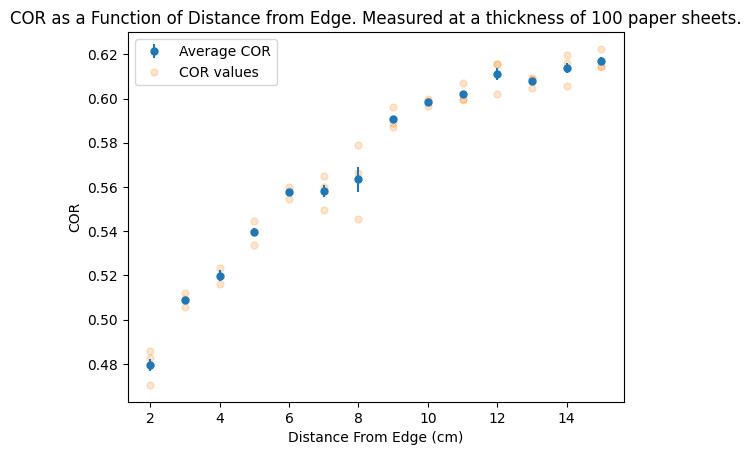

In [26]:
plt.errorbar(edge_unique_100t, avg_COR_100t, yerr=COR_err_100t, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.errorbar(edge_100t, COR_100t, fmt = 'o', markersize=5, label='COR values', zorder = 1, alpha = 0.2)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()

Selfmadefuntions imported/reloaded


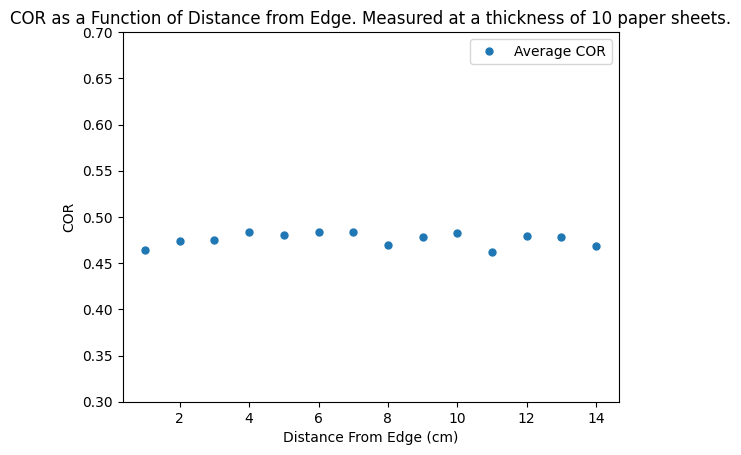

In [27]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_10t")

variable_type = "distance from edge"
edge_10t = [i for i in range(1, 15)]
COR_10t = []

for i in range(1, 15):
    variable_value = f"{i} cm"
    
    for j in range(1, 2):
        filename = f"20h_10t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_10t.append(cor_value)


plt.errorbar(edge_10t, COR_10t, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.ylim(0.3, 0.7)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 10 paper sheets.')
plt.legend()
plt.show()

In [28]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

variable_type = "distance from edge"
edge_300t = np.repeat(np.arange(2, 16), 3)
COR_300t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_300t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_300t.append(cor_value)

COR_300t[16] = np.nan
COR_300t[20] = np.nan


Selfmadefuntions imported/reloaded


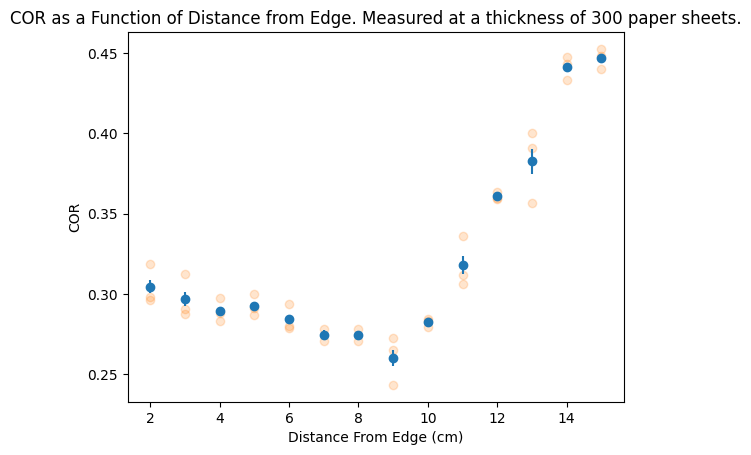

In [29]:
importlib.reload(selfmadefunctions)
edge_300t_clean, COR_300t_clean, COR_300t_err, avg_COR_300t, edge_unique_300t = selfmadefunctions.get_avg_err(edge_300t, COR_300t)

plt.errorbar(edge_unique_300t, avg_COR_300t, COR_300t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_300t_clean, COR_300t_clean, fmt = 'o', alpha = 0.2, zorder = 1)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 300 paper sheets.')
plt.show()

In [30]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_5t")

variable_type = "distance from edge"
unique_edge_5t = [2, 6, 9, 10, 11, 12, 13, 14]
edge_5t = np.repeat(unique_edge_5t, 3)
COR_5t = []



for i in unique_edge_5t:
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_5t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_5t.append(cor_value)

print(COR_5t)

for i in range(len(COR_5t)):
    if COR_5t[i] > 1:
        COR_5t[i] = np.nan

[np.float64(0.5005062283258126), np.float64(0.5062782746829388), np.float64(0.5011458150968233), np.float64(0.4801940743031168), np.float64(0.49791018205539683), np.float64(0.48246731099254764), np.float64(0.49743419024341423), np.float64(0.5003336142926887), np.float64(inf), np.float64(0.4945291988883488), np.float64(0.4938173142313406), np.float64(0.4971936077961293), np.float64(0.5045963721132011), np.float64(0.5068722762242563), np.float64(0.4977704219937071), np.float64(0.5043415765646206), np.float64(0.4923159944655176), np.float64(0.5024839707225935), np.float64(0.5095900881885473), np.float64(inf), np.float64(0.4863496496730499), np.float64(0.502577470746329), np.float64(0.4936256689039066), np.float64(0.5016444245034546)]


c:\Users\DTA180363\Documents\GitHub\paperstack\Manou_version\code\selfmadefunctions.py:520: RuntimeWarning: divide by zero encountered in scalar divide
  COR = np.sqrt(bounce_height / drop_height)


Selfmadefuntions imported/reloaded


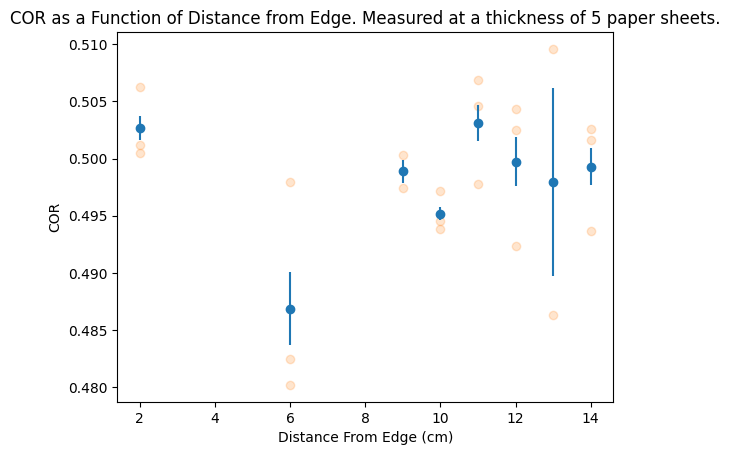

In [31]:
importlib.reload(selfmadefunctions)
edge_5t_clean, COR_5t_clean, COR_5t_err, avg_COR_5t, x_unique = selfmadefunctions.get_avg_err(edge_5t, COR_5t)


plt.errorbar(unique_edge_5t, avg_COR_5t, COR_5t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_5t_clean, COR_5t_clean, fmt = 'o', alpha = 0.2, zorder = 1)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 5 paper sheets.')
plt.show()

In [39]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_50t")
importlib.reload(selfmadefunctions)

variable_type = "distance from edge"
edge_50t = np.repeat(np.arange(2, 16), 3)
COR_50t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_50t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_50t.append(cor_value)

edge_50t_clean, COR_50t_clean, COR_50t_err, avg_COR_50t, edge_50t_unique = selfmadefunctions.get_avg_err(edge_50t, COR_50t)

Selfmadefuntions imported/reloaded


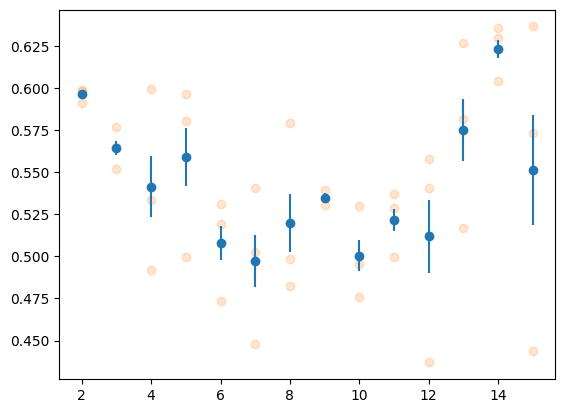

In [33]:
plt.errorbar(edge_50t_unique, avg_COR_50t,  COR_50t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_50t_clean, COR_50t_clean, fmt = 'o', zorder = 1, alpha = 0.2)
plt.show()

Selfmadefuntions imported/reloaded


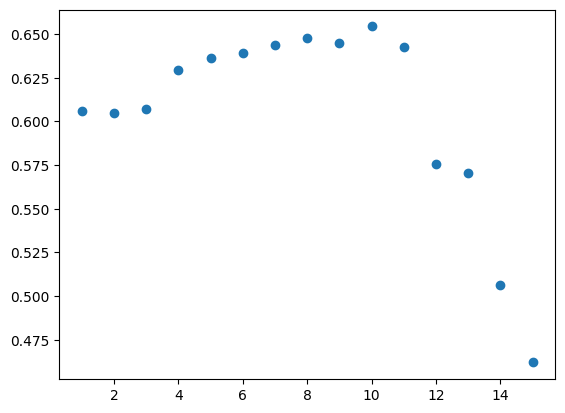

In [40]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry")
importlib.reload(selfmadefunctions)

variable_type = "distance from edge"
edge_50t_retry = np.arange(1, 16)
COR_50t_retry = []

for i in range(1, 16):
    variable_value = f"{i} cm"
    filename = f"50t_retry_{i}_clean"
    cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                variable_type=variable_type, 
                                                                variable_value=variable_value, 
                                                                filename=filename, Find_Plot=False,
                                                                Fit_Plot=False, Fit_Report=False)
    COR_50t_retry.append(cor_value)


plt.errorbar(edge_50t_retry, COR_50t_retry, fmt = 'o')
plt.show()

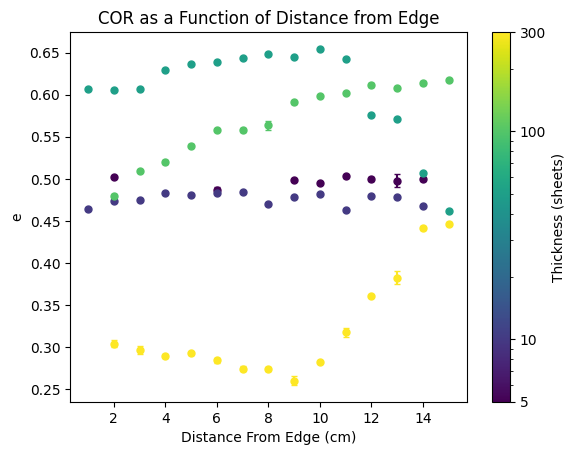

In [42]:
# thickness values
thicknesses = [5, 10, 50, 100, 300]

# normalize thickness range for the colormap
norm = mpl.colors.LogNorm(vmin=min(thicknesses), vmax=max(thicknesses))
cmap = plt.cm.viridis   # you can also try plasma, turbo, inferno

fig, ax = plt.subplots()

ax.errorbar(unique_edge_5t,   avg_COR_5t,   yerr=COR_5t_err,   fmt='o',
            color=cmap(norm(5)),   markersize=5, capsize=2, label='5 sheets')
ax.errorbar(edge_10t,         COR_10t,      fmt='o',
            color=cmap(norm(10)),  markersize=5, capsize=2, label='10 sheets')
ax.errorbar(edge_50t_retry, COR_50t_retry, fmt = 'o',
            color=cmap(norm(50)),   markersize=5, capsize=2, label='50 sheets')
ax.errorbar(edge_unique_100t, avg_COR_100t, yerr=COR_err_100t, fmt='o',
            color=cmap(norm(100)), markersize=5, capsize=2, label='100 sheets')
ax.errorbar(edge_unique_300t, avg_COR_300t, yerr=COR_300t_err, fmt='o',
            color=cmap(norm(300)), markersize=5, capsize=2, label='300 sheets')

ax.set_xlabel('Distance From Edge (cm)')
ax.set_ylabel('e')
ax.set_title('COR as a Function of Distance from Edge')

# colorbar instead of relying only on legend
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Thickness (sheets)')
cbar.set_ticks([5, 10, 100, 300])
cbar.set_ticklabels([5, 10, 100, 300])
plt.show()